# A2C with NARX Critic on ImprovedB747Env

This notebook demonstrates Advantage Actor-Critic (A2C) with a NARX-based critic on the ImprovedB747Env. The critic consumes fixed-size history features built from past observations and actions, improving value estimates under partial observability and delays.


In [1]:
import os
import numpy as np
import torch
from torch.nn import functional as F

from tensoraerospace.agent.a2c.model import A2C, Actor, Critic
from tensoraerospace.agent.a2c.model import process_memory, clip_grad_norm_
from tensoraerospace.agent.a2c.narx_critic import NARXCritic, build_narx_features
from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.signals.standart import sinusoid_vertical_shift
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print("Using device:", DEVICE)

np.random.seed(1)
_ = torch.manual_seed(1)


Using device: mps


In [2]:
# Environment setup (mirrors PPO example)
dt = 0.1
_tp = generate_time_period(tn=20, dt=dt)
tps = convert_tp_to_sec_tp(_tp, dt=dt)
number_time_steps = len(_tp)

reference_signals = np.reshape(
    sinusoid_vertical_shift(
        tp=np.asarray(tps),
        frequency=0.05,
        amplitude=np.deg2rad(1.0),
        vertical_shift=0.0,
    ),
    [1, -1],
)

init_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)

env = ImprovedB747Env(
    initial_state=init_state,
    reference_signal=reference_signals,
    number_time_steps=number_time_steps,
    dt=dt,
    initial_elevator_deg=0.0,
)

obs, info = env.reset()
print("Observation shape:", np.array(obs).shape)
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)


Observation shape: (4,)
Action space: Box(-1.0, 1.0, (1,), float32)
Observation space: Box(-1.0, 1.0, (4,), float32)


In [3]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

# Standard A2C actor (Gaussian policy)
actor = Actor(state_dim, action_dim)

# NARX critic configuration
HISTORY = 4
narx_critic = NARXCritic(
    observation_dim=state_dim,
    action_dim=action_dim,
    history_length=HISTORY,
    hidden_sizes=(128, 128),
)

# Helper buffers for building NARX features during learning
from collections import deque
obs_window = deque(maxlen=HISTORY)
act_window = deque(maxlen=HISTORY)

# Initialize windows with zeros for the first steps
for _ in range(HISTORY):
    obs_window.append(np.zeros(state_dim, dtype=np.float32))
    act_window.append(np.zeros(action_dim, dtype=np.float32))


In [4]:
class A2CWithNARXCritic(A2C):
    def __init__(self, *args, history_length: int = 4, **kwargs):
        super().__init__(*args, **kwargs)
        self.history_length = history_length

    def _build_narx_batch(self, states: torch.Tensor, actions: torch.Tensor) -> torch.Tensor:
        # states: (T, state_dim), actions: (T, action_dim)
        return build_narx_features(states, actions, self.history_length)

    def learn(self, memory, steps, discount_rewards=True):
        actions, rewards, states, next_states, dones = process_memory(
            memory, self.gamma, discount_rewards, device=self.device
        )

        # TD target
        if discount_rewards:
            td_target = rewards.detach()
        else:
            with torch.no_grad():
                # for TD(0) with NARX critic we need next-state features; we approximate using same feature builder
                next_features = self._build_narx_batch(next_states, actions)
                next_value = self.critic(next_features)
            td_target = rewards + self.gamma * next_value * (1 - dones)

        # Critic update (with NARX features)
        features = self._build_narx_batch(states, actions)
        value = self.critic(features)
        critic_loss = F.mse_loss(value, td_target)
        self.critic_optim.zero_grad()
        critic_loss.backward()
        clip_grad_norm_(self.critic_optim, self.max_grad_norm)
        self.critic_optim.step()

        # Advantage with updated critic
        with torch.no_grad():
            value_updated = self.critic(features)
            advantage = td_target - value_updated
            advantage_normalized = (advantage - advantage.mean()) / (advantage.std() + 1e-8)

        # Actor update (standard A2C)
        norm_dists = self.actor(states)
        log_probs = norm_dists.log_prob(actions)
        if log_probs.dim() > 1:
            log_probs = log_probs.sum(dim=-1, keepdim=True)
        entropy = norm_dists.entropy()
        if entropy.dim() > 1:
            entropy = entropy.sum(dim=-1).mean()

        actor_loss = -(log_probs * advantage_normalized).mean() - self.entropy_beta * entropy
        self.actor_optim.zero_grad()
        actor_loss.backward()
        clip_grad_norm_(self.actor_optim, self.max_grad_norm)
        self.actor_optim.step()

        # Logging
        self.writer.add_scalar("Loss/Actor", actor_loss, global_step=steps)
        self.writer.add_scalar("Loss/Critic", critic_loss, global_step=steps)
        self.writer.add_scalar("Advantage/Mean", advantage.mean(), global_step=steps)
        self.writer.add_scalar("Policy/Action_Std", norm_dists.stddev.mean(), global_step=steps)


In [ ]:
# Create agent with NARX critic
agent = A2CWithNARXCritic(
    env=env,
    actor=actor.to(DEVICE),
    critic=narx_critic.to(DEVICE),
    gamma=0.99,
    entropy_beta=0.1,
    actor_lr=3e-4,
    critic_lr=1e-3,
    max_grad_norm=0.5,
    seed=123,
    device=DEVICE,
    history_length=HISTORY,
)

print("Actor params:", sum(p.numel() for p in agent.actor.parameters()))
print("Critic params:", sum(p.numel() for p in agent.critic.parameters()))


A2C initialized on device: mps
Actor params: 4546
Critic params: 19329


In [33]:
# Quick training run
stats = agent.train(
    steps_on_memory=128,
    episodes=500,
    episode_length=number_time_steps,
    discount_rewards=True,
    log_freq=100,
)

print("Training done. Total steps:", stats["total_steps"])


Training:   0%|          | 1/785 [00:00<07:03,  1.85it/s]

Step 100608 | Episodes: 505 | Avg Reward (last 10): -0.39


Training:  13%|█▎        | 101/785 [00:32<03:12,  3.55it/s]

Step 113408 | Episodes: 569 | Avg Reward (last 10): -0.41


Training:  26%|██▌       | 201/785 [01:05<03:10,  3.06it/s]

Step 126208 | Episodes: 634 | Avg Reward (last 10): -0.43


Training:  38%|███▊      | 301/785 [01:39<02:33,  3.15it/s]

Step 139008 | Episodes: 698 | Avg Reward (last 10): -0.45


Training:  44%|████▍     | 345/785 [01:56<02:28,  2.97it/s]


KeyboardInterrupt: 

In [29]:
# Evaluation run
obs, info = env.reset()
done = False
ret = 0.0
step = 0

while not done and step < number_time_steps:
    action = agent.predict(obs, deterministic=True)
    step_return = env.step(action)
    if len(step_return) == 5:
        obs, reward, terminated, truncated, info = step_return
        done = terminated or truncated
    else:
        obs, reward, terminated, info = step_return[:4]
        done = terminated
    ret += float(reward)
    step += 1

print(f"Evaluation reward: {ret:.3f}")


Evaluation reward: -0.031


Theta (pitch angle) tracking:


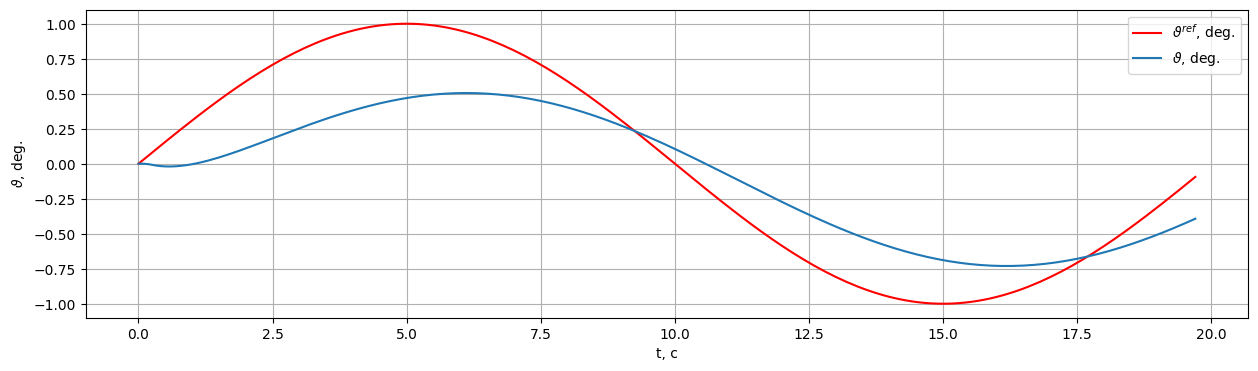

In [30]:
# Plot theta (pitch angle) tracking
print("Theta (pitch angle) tracking:")
env.unwrapped.model.plot_transient_process(
    'theta', 
    tps, 
    reference_signals[0], 
    to_deg=True, 
    figsize=(15, 4)
)


Pitch rate (q):


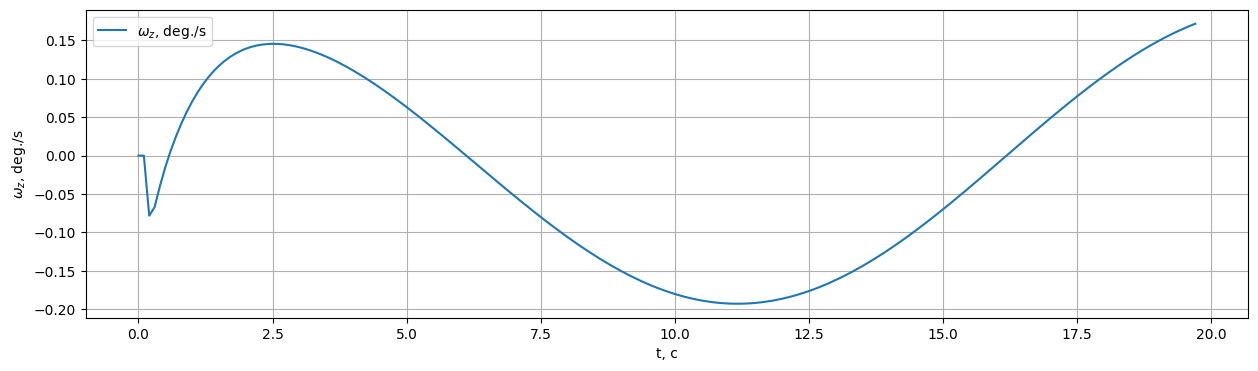

In [31]:
# Plot pitch rate (q)
print("Pitch rate (q):")
env.unwrapped.model.plot_state(
    state_name='q', 
    time=tps, 
    to_deg=True, 
    figsize=(15, 4)
)


Elevator control input:


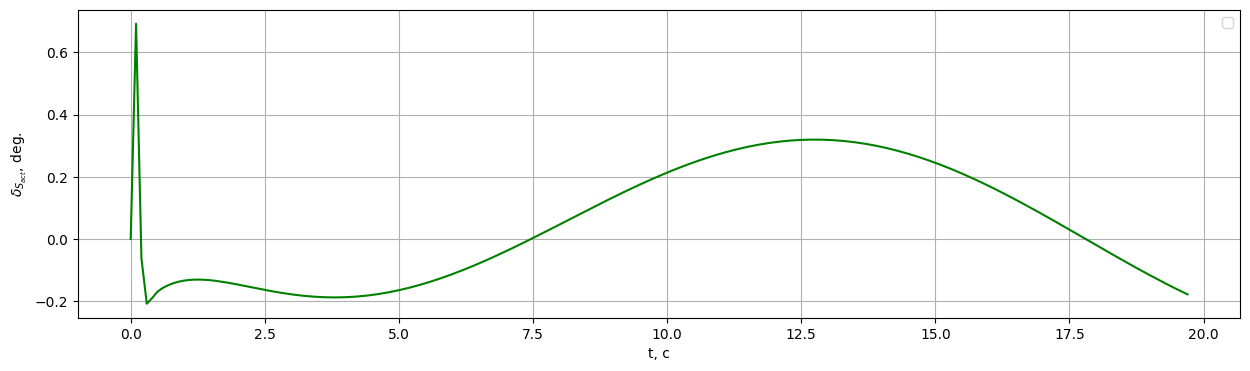

In [32]:
# Plot elevator control
print("Elevator control input:")
env.unwrapped.model.plot_control(
    control_name='ele', 
    time=tps, 
    to_deg=True, 
    figsize=(15, 4)
)
